# Dataset — detección YOLO (`datasets/yolo_detection/`)

## Qué es esto

Notebook de **inspección de dataset**, no de experimento: describe las imágenes y etiquetas que
`08_deteccion_yolo.ipynb` usa para entrenar/evaluar YOLO --
`datasets/yolo_detection/images/{train,val,test}/*.png` + `labels/{train,val,test}/*.txt`
(formato YOLO: `clase xc yc w h` normalizado a [0,1]; `movil`=0, `estatico`=1).

Todo acá se lee **directo de los archivos exportados**, igual que
`scripts/ver_etiquetas_deteccion.py` -- así se ve exactamente lo que YOLO consume, no lo que
`positions.csv` dice (si hubiera un bug de exportación, tiene que aparecer acá). La única
excepción es la sección 0.1, que cruza contra `positions.csv` una sola vez para confirmar qué
parámetro de exportación produjo las etiquetas congeladas en disco.

El dataset se genera con `scripts/exportar_etiquetas_deteccion.py` a partir de
`datasets/{train,val,test}/sample_*` (synthkymo) -- ver `docs/regenerar-dataset-sintetico.md`
para el pipeline completo y `src/axonal_tracking/etiquetas_deteccion.py` para la geometría
caja/clase.


---

## 0. Setup


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image
import yaml

sys.path.append(str(Path("../..") / "src"))
from axonal_tracking import etiquetas_deteccion as ed

RAIZ = Path("../..").resolve()
DATASETS = RAIZ / "datasets"
YOLO_DIR = DATASETS / "yolo_detection"
DATA_YAML = YOLO_DIR / "kymograph_detection.yaml"
SPLITS = ("train", "val", "test")

assert DATA_YAML.exists(), (
    f"No existe {DATA_YAML}. Correr scripts/exportar_etiquetas_deteccion.py primero."
)
data_cfg = yaml.safe_load(DATA_YAML.read_text())
print("data-config:", DATA_YAML)
print(data_cfg)


data-config: /Users/alejandrovalle/Desktop/Posgrado/CEIA/axonal-tracking/datasets/yolo_detection/kymograph_detection.yaml
{'path': '/Users/alejandrovalle/Desktop/Posgrado/CEIA/axonal-tracking/datasets/yolo_detection', 'train': 'images/train', 'val': 'images/val', 'test': 'images/test', 'names': {0: 'movil', 1: 'estatico'}}


---

## 0.1 Procedencia -- ¿qué threshold movil/estático produjo estas etiquetas?

`exportar_etiquetas_deteccion.py` acepta `--min-desplazamiento-px` (default en el script:
**1.0**); pero `08_deteccion_yolo.ipynb` evalúa contra GT con **8.0** (el valor del laboratorio,
`docs/handover.md` §2.3) y advierte que ambos *tienen* que coincidir o la evaluación mide contra
un ground truth distinto del que YOLO vio. `docs/regenerar-dataset-sintetico.md` §2 muestra el
comando de export **sin** el flag -- no alcanza para saber qué se usó realmente.

Chequeo barato: recalcular las cajas desde `positions.csv` con ambos thresholds candidatos y
comparar el conteo por clase contra el `.txt` en disco, sobre una muestra al azar de cada split.
El que coincida siempre es el que se usó.


In [2]:
import random

random.seed(0)
CANDIDATOS = (1.0, 8.0)
matches = {c: 0 for c in CANDIDATOS}
n_chequeadas = 0

for split in SPLITS:
    raw_dir = DATASETS / split
    if not raw_dir.is_dir():
        continue
    muestras_split = sorted(raw_dir.glob("sample_*"))
    for sample in random.sample(muestras_split, min(5, len(muestras_split))):
        lbl_path = YOLO_DIR / "labels" / split / f"{sample.name}.txt"
        if not lbl_path.exists():
            continue
        ondisk = [int(l.split()[0]) for l in lbl_path.read_text().splitlines() if l.strip()]
        ondisk_conteo = (ondisk.count(ed.CLASE_MOVIL), ondisk.count(ed.CLASE_ESTATICO))

        kymo = ed._leer_kymografo_tif(sample / "kymograph.tif")
        T, L = np.asarray(kymo).shape[:2]
        positions = pd.read_csv(sample / "positions.csv")
        px = float(yaml.safe_load((sample / "config.yaml").read_text())["general"]["pixel_scale_um"])

        n_chequeadas += 1
        for thr in CANDIDATOS:
            cajas = ed.cajas_desde_positions(positions, px, (T, L), min_desplazamiento_px=thr)
            conteo = (
                sum(1 for c in cajas if c.clase == ed.CLASE_MOVIL),
                sum(1 for c in cajas if c.clase == ed.CLASE_ESTATICO),
            )
            if conteo == ondisk_conteo:
                matches[thr] += 1

print(f"{n_chequeadas} muestras chequeadas (aleatorias, los 3 splits)")
for thr, n in matches.items():
    print(f"  min_desplazamiento_px={thr}: coincide en {n}/{n_chequeadas}")

if all(n == n_chequeadas for n in matches.values()):
    print(
        "\nambos thresholds coinciden en TODAS las muestras -- la ambigüedad no afecta a este "
        "dataset (haría falta una partícula que se mueva entre 1 y 8px para distinguirlos, y no "
        "pasó en la muestra chequeada)."
    )
else:
    THRESHOLD_VERIFICADO = max(matches, key=matches.get)
    assert matches[THRESHOLD_VERIFICADO] == n_chequeadas, (
        "ningún threshold candidato coincide en TODAS las muestras -- las etiquetas en disco no "
        "corresponden a un único threshold fijo, revisar a mano."
    )
    print(f"\n-> threshold usado para exportar las etiquetas en disco: {THRESHOLD_VERIFICADO}")


15 muestras chequeadas (aleatorias, los 3 splits)
  min_desplazamiento_px=1.0: coincide en 11/15
  min_desplazamiento_px=8.0: coincide en 15/15

-> threshold usado para exportar las etiquetas en disco: 8.0


---

## 1. Resumen por split

Conteo de imágenes/etiquetas y chequeos de paridad -- si esto no cuadra, algo se rompió en la
exportación antes de llegar a cualquier estadística de más abajo.


In [3]:
def leer_cajas_yolo(lbl_path: Path) -> list[tuple[int, float, float, float, float]]:
    """Lee un `.txt` YOLO (`clase xc yc w h`, normalizado) tal cual lo consume ultralytics --
    mismo parseo que `scripts/ver_etiquetas_deteccion.py`."""
    if not lbl_path.exists():
        return []
    cajas = []
    for linea in lbl_path.read_text().splitlines():
        if not linea.strip():
            continue
        cls, xc, yc, w, h = linea.split()
        cajas.append((int(cls), float(xc), float(yc), float(w), float(h)))
    return cajas


filas_img, filas_box = [], []
for split in SPLITS:
    img_dir, lbl_dir = YOLO_DIR / "images" / split, YOLO_DIR / "labels" / split
    for img_path in sorted(img_dir.glob("*.png")):
        with Image.open(img_path) as im:
            L, T = im.size  # PIL: (ancho, alto) = (L, T) del kymógrafo
        cajas = leer_cajas_yolo(lbl_dir / f"{img_path.stem}.txt")
        filas_img.append({
            "split": split, "muestra": img_path.stem, "L": L, "T": T,
            "aspect_ratio": L / T, "n_cajas": len(cajas),
            "n_movil": sum(1 for c in cajas if c[0] == ed.CLASE_MOVIL),
            "n_estatico": sum(1 for c in cajas if c[0] == ed.CLASE_ESTATICO),
        })
        for cls, xc, yc, w, h in cajas:
            filas_box.append({
                "split": split, "muestra": img_path.stem, "clase": cls,
                "L": L, "w_px": w * L, "h_px": h * T,
            })

img_df = pd.DataFrame(filas_img)
box_df = pd.DataFrame(filas_box)

resumen = img_df.groupby("split").agg(
    n_imagenes=("muestra", "count"),
    n_cajas=("n_cajas", "sum"),
    n_movil=("n_movil", "sum"),
    n_estatico=("n_estatico", "sum"),
).reindex(list(SPLITS))
print(resumen)

# paridad imagen<->etiqueta: toda imagen exportada tiene que tener su .txt (aunque esté vacío)
print()
for split in SPLITS:
    n_img = len(list((YOLO_DIR / "images" / split).glob("*.png")))
    n_lbl = len(list((YOLO_DIR / "labels" / split).glob("*.txt")))
    flag = "" if n_img == n_lbl else "  <-- DESCUADRA"
    print(f"{split}: {n_img} imágenes, {n_lbl} etiquetas{flag}")

sin_cajas = img_df[img_df.n_cajas == 0]
print(f"\nimágenes sin ninguna caja: {len(sin_cajas)}")


       n_imagenes  n_cajas  n_movil  n_estatico
split                                          
train         800    22000     4534       17466
val           400    11000     2266        8734
test          400    11000     2265        8735

train: 800 imágenes, 800 etiquetas
val: 400 imágenes, 400 etiquetas
test: 400 imágenes, 400 etiquetas

imágenes sin ninguna caja: 0


### 1.1 Ejemplo de etiquetas crudas

Contenido literal del `.txt` (`clase xc yc w h`, normalizado) de una muestra por split, tal cual
lo lee YOLO -- antes de agregar nada en las secciones de más abajo.


In [4]:
EJEMPLOS = [sorted((YOLO_DIR / "images" / split).glob("*.png"))[0].stem for split in SPLITS]

for split, nombre in zip(SPLITS, EJEMPLOS):
    lbl_path = YOLO_DIR / "labels" / split / f"{nombre}.txt"
    print(f"===== {split}/{nombre}.txt (contenido crudo) =====")
    print(lbl_path.read_text())

    tabla = pd.DataFrame(leer_cajas_yolo(lbl_path), columns=["clase", "xc", "yc", "w", "h"])
    tabla["clase"] = tabla["clase"].map(dict(enumerate(ed.CLASES)))
    print(tabla.to_string(index=False))
    print()


===== train/sample_00000.txt (contenido crudo) =====
1 0.204348 0.498588 0.009792 0.997175
1 0.072076 0.498588 0.009968 0.997175
1 0.777856 0.498588 0.006426 0.997175
0 0.644744 0.498588 0.068145 0.997175
1 0.082636 0.498588 0.006930 0.997175
1 0.854357 0.498588 0.011046 0.997175
1 0.741614 0.498588 0.007450 0.997175
0 0.148350 0.498588 0.025802 0.997175
1 0.566887 0.498588 0.007166 0.997175
1 0.499430 0.498588 0.005366 0.997175
1 0.311788 0.498588 0.005183 0.997175
1 0.974197 0.498588 0.005365 0.997175
1 0.126643 0.498588 0.006763 0.997175
1 0.120692 0.498588 0.008542 0.997175
1 0.233120 0.498588 0.007642 0.997175
1 0.807891 0.498588 0.008910 0.997175
1 0.497856 0.498588 0.006632 0.997175
1 0.238457 0.498588 0.011320 0.997175
1 0.266129 0.498588 0.008683 0.997175
1 0.802732 0.498588 0.005149 0.997175
1 0.214379 0.498588 0.006214 0.997175
1 0.143010 0.498588 0.006755 0.997175
1 0.846472 0.498588 0.010636 0.997175
1 0.858938 0.498588 0.010689 0.997175

   clase       xc       yc        

---

## 2. Balance de clases

`movil` (0) vs `estatico` (1) -- **dos clases a propósito**: una caja móvil puede solaparse con
una estática, así que el detector tiene que aprender a diferenciarlas en vez de ignorar las
estáticas (ver comentario sobre `CLASE_MOVIL`/`CLASE_ESTATICO` en `etiquetas_deteccion.py`). El
desbalance entre clases es la razón por la que `08_deteccion_yolo.ipynb` §3 mira **mAP por
clase**, no sólo el agregado.


       movil  estatico  ratio_estatico:movil
split                                       
train   4534     17466                  3.85
val     2266      8734                  3.85
test    2265      8735                  3.86


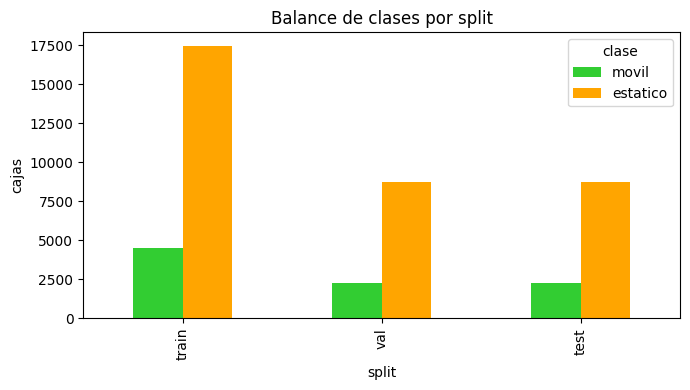

In [5]:
balance = box_df.groupby(["split", "clase"]).size().unstack(fill_value=0)
balance.columns = [ed.CLASES[c] for c in balance.columns]
balance = balance.reindex(list(SPLITS))
balance["ratio_estatico:movil"] = (balance["estatico"] / balance["movil"]).round(2)
print(balance)

fig, ax = plt.subplots(figsize=(7, 4))
balance[["movil", "estatico"]].plot(kind="bar", ax=ax, color=["limegreen", "orange"])
ax.set_ylabel("cajas")
ax.set_title("Balance de clases por split")
ax.legend(title="clase")
plt.tight_layout()
plt.show()


---

## 3. Cajas por imagen


       mean   50%   min   max
split                        
test   27.5  25.0  20.0  44.0
train  27.5  25.0  20.0  44.0
val    27.5  25.0  20.0  44.0


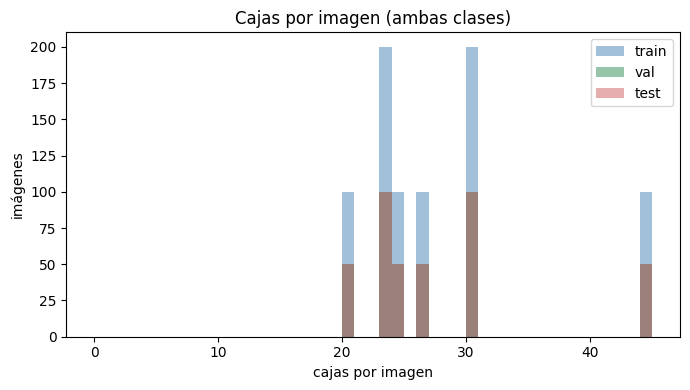

In [6]:
print(img_df.groupby("split")["n_cajas"].describe()[["mean", "50%", "min", "max"]].round(1))

fig, ax = plt.subplots(figsize=(7, 4))
for split, color in zip(SPLITS, ["steelblue", "seagreen", "indianred"]):
    sub = img_df[img_df.split == split]["n_cajas"]
    ax.hist(sub, bins=range(0, int(img_df.n_cajas.max()) + 2), alpha=0.5, label=split, color=color)
ax.set_xlabel("cajas por imagen")
ax.set_ylabel("imágenes")
ax.set_title("Cajas por imagen (ambas clases)")
ax.legend()
plt.tight_layout()
plt.show()


---

## 4. Geometría de las cajas

Ancho (`w_px`, eje posición) y alto (`h_px`, eje tiempo) de cada caja, en píxeles del kymógrafo
(antes de cualquier resize de YOLO). `estatico` son líneas verticales angostas y largas en
tiempo; `movil` son diagonales que ocupan más ancho -- se espera que `w_px`/`h_px` por clase
reflejen eso.


clase            0        1
w_px count  9065.0  34935.0
     mean     79.6     10.7
     std      76.0      3.1
     min      12.6      2.0
     25%      31.2      8.1
     50%      43.9     10.6
     75%      99.3     13.1
     max     456.3     23.9
h_px count  9065.0  34935.0
     mean    210.9    238.5
     std     127.4    109.7
     min       7.5      0.5
     25%      88.5    170.5
     50%     195.5    234.5
     75%     326.5    327.5
     max     464.5    464.5


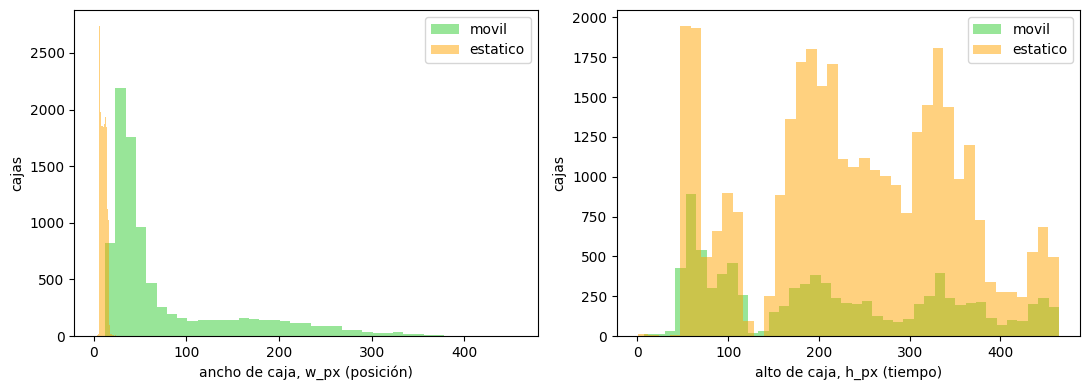

In [7]:
print(box_df.groupby("clase")[["w_px", "h_px"]].describe().round(1).T)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for clase, color in zip((ed.CLASE_MOVIL, ed.CLASE_ESTATICO), ["limegreen", "orange"]):
    sub = box_df[box_df.clase == clase]
    axes[0].hist(sub["w_px"], bins=40, alpha=0.5, label=ed.CLASES[clase], color=color)
    axes[1].hist(sub["h_px"], bins=40, alpha=0.5, label=ed.CLASES[clase], color=color)
axes[0].set_xlabel("ancho de caja, w_px (posición)")
axes[1].set_xlabel("alto de caja, h_px (tiempo)")
for ax in axes:
    ax.set_ylabel("cajas")
    ax.legend()
plt.tight_layout()
plt.show()


### 4.1 Cajas degeneradas (visibles en un solo frame)

`cajas_desde_positions` fija `y1=frame.min()-0.5`, `y2=frame.max()+0.5` -- una partícula visible
en un único frame da `h_px≈1`; si además su ancho renderizado (`size_um`) es chico, `w_px`
también puede quedar en el orden de 1-3px. El guard de la función descarta cajas con
`w<0.5` o `h<0.5`, pero no éstas -- son válidas (la partícula existe un frame), sólo chicas.


In [8]:
degeneradas = box_df[(box_df.h_px <= 1.0) | (box_df.w_px <= 3.0)]
print(f"{len(degeneradas)} / {len(box_df)} cajas degeneradas "
      f"({100 * len(degeneradas) / len(box_df):.2f}%)")
print(degeneradas.groupby(["split", "clase"]).size())


12 / 44000 cajas degeneradas (0.03%)
split  clase
test   1        4
train  1        6
val    1        2
dtype: int64


---

## 5. Aspect ratio de las imágenes

`aspect_ratio = L / T` (posición / tiempo) -- determina cuánto comprime `rect=True` el eje
temporal al reescalar a `imgsz` (`08_deteccion_yolo.ipynb` §2). Los percentiles de **test**
citados en ese notebook (p50=7.1:1, p90=12.1:1, p99=19.1:1) son de una corrida anterior del
dataset -- recalculados acá contra el dataset actual en disco; si no coinciden, es porque
`datasets/` se regeneró después de escribir ese texto
(`docs/regenerar-dataset-sintetico.md`), no un bug de este notebook.


In [9]:
def bucket_ar(ar):
    if ar < 8:
        return "<8:1"
    if ar < 15:
        return "8-15:1"
    if ar < 25:
        return "15-25:1"
    return ">25:1"


ORDEN_BUCKETS = ["<8:1", "8-15:1", "15-25:1", ">25:1"]

print("percentiles de aspect ratio, sólo test (comparar contra 08_deteccion_yolo.ipynb §2):")
print(img_df[img_df.split == "test"]["aspect_ratio"].quantile([0.5, 0.9, 0.99]).round(1))

print("\npercentiles de aspect ratio, dataset completo:")
print(img_df["aspect_ratio"].quantile([0.5, 0.9, 0.99]).round(1))

img_df["bucket_ar"] = img_df["aspect_ratio"].apply(bucket_ar)
print("\nmuestras por bucket y split:")
print(
    img_df.groupby(["split", "bucket_ar"]).size()
    .unstack(fill_value=0)
    .reindex(columns=ORDEN_BUCKETS, fill_value=0)
    .reindex(list(SPLITS))
)


percentiles de aspect ratio, sólo test (comparar contra 08_deteccion_yolo.ipynb §2):
0.50     6.1
0.90    17.6
0.99    30.2
Name: aspect_ratio, dtype: float64

percentiles de aspect ratio, dataset completo:
0.50     6.1
0.90    17.8
0.99    30.3
Name: aspect_ratio, dtype: float64

muestras por bucket y split:
bucket_ar  <8:1  8-15:1  15-25:1  >25:1
split                                  
train       539     151       72     38
val         272      72       43     13
test        279      58       48     15


---

## 6. `rect=True` a `imgsz=1536` vs. techo del head DFL

El cierre de NB08/NB09 (`plan/notebooks-08-09-closeout.md` §4.1) documenta una segunda causa de
geometría rota: incluso con `imgsz=1536`, la cabeza DFL de YOLO tiene un alcance máximo de
`reg_max × stride ≈ 480px` para expresar la altura de una caja -- pero algunas trazas necesitan
~900px. Acá se mide directo sobre las cajas reales del dataset: para cada caja, el alto que
tendría *después* del resize `rect=True` es `h_px * imgsz / L` (mismo factor de escala que
comprime la imagen entera, `08_deteccion_yolo.ipynb` §2). Qué fracción de esas alturas
post-resize supera los ~480px es la evidencia directa de cuánto pierde la cabeza DFL.


        mean    50%     max
clase                      
0      281.4  232.3  2984.4
1      321.3  282.9  2984.4

fracción de cajas con alto post-resize > 480px (techo DFL), por clase:
clase
0    12.0%
1    13.8%
Name: sobre_techo, dtype: str

total: 13.5% de todas las cajas


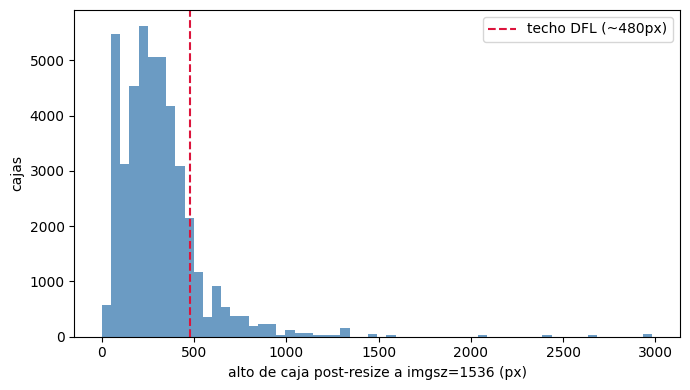

In [10]:
IMGSZ = 1536
TECHO_DFL_PX = 480  # reg_max * stride, plan/notebooks-08-09-closeout.md SS4.1

box_df["h_resized"] = box_df["h_px"] * IMGSZ / box_df["L"]

print(box_df.groupby("clase")["h_resized"].describe()[["mean", "50%", "max"]].round(1))

fraccion_sobre_techo = (
    box_df.assign(sobre_techo=box_df["h_resized"] > TECHO_DFL_PX)
    .groupby("clase")["sobre_techo"].mean()
)
print(f"\nfracción de cajas con alto post-resize > {TECHO_DFL_PX}px (techo DFL), por clase:")
print((fraccion_sobre_techo * 100).round(1).astype(str) + "%")
print(f"\ntotal: {100 * (box_df['h_resized'] > TECHO_DFL_PX).mean():.1f}% de todas las cajas")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(box_df["h_resized"], bins=60, color="steelblue", alpha=0.8)
ax.axvline(TECHO_DFL_PX, color="crimson", linestyle="--", label=f"techo DFL (~{TECHO_DFL_PX}px)")
ax.set_xlabel("alto de caja post-resize a imgsz=1536 (px)")
ax.set_ylabel("cajas")
ax.legend()
plt.tight_layout()
plt.show()


---

## 7. Muestras visuales

Una muestra al azar por split con las cajas dibujadas **tal cual están en el `.txt`
exportado** (no recalculadas) -- mismo criterio que `scripts/ver_etiquetas_deteccion.py`, sólo
que acá se grafica inline en vez de guardar PNGs.


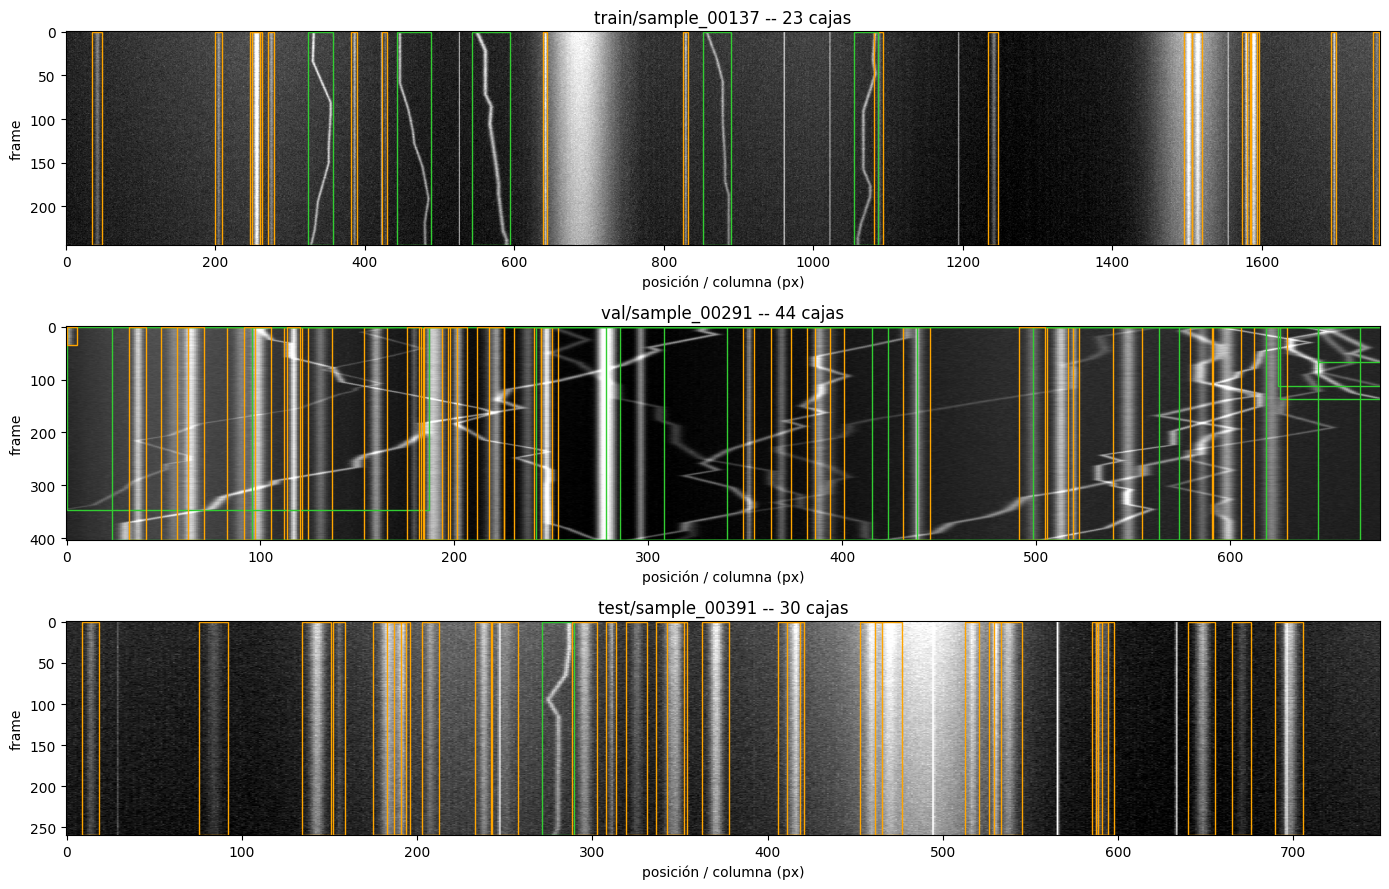

In [11]:
random.seed(1)
fig, axes = plt.subplots(len(SPLITS), 1, figsize=(14, 3 * len(SPLITS)))

color_clase = {ed.CLASE_MOVIL: "limegreen", ed.CLASE_ESTATICO: "orange"}
for ax, split in zip(axes, SPLITS):
    img_path = random.choice(sorted((YOLO_DIR / "images" / split).glob("*.png")))
    with Image.open(img_path) as im:
        L, T = im.size
        arr = np.asarray(im.convert("L"))
    cajas = leer_cajas_yolo(YOLO_DIR / "labels" / split / f"{img_path.stem}.txt")

    ax.imshow(arr, cmap="gray", aspect="auto",
              vmin=np.percentile(arr, 1), vmax=np.percentile(arr, 99.5))
    for cls, xc, yc, w, h in cajas:
        x1, y1 = (xc - w / 2) * L, (yc - h / 2) * T
        ax.add_patch(Rectangle((x1, y1), w * L, h * T, edgecolor=color_clase[cls],
                                facecolor="none", linewidth=1))
    ax.set_title(f"{split}/{img_path.stem} -- {len(cajas)} cajas")
    ax.set_xlabel("posición / columna (px)")
    ax.set_ylabel("frame")

plt.tight_layout()
plt.show()
